## 1 . Import các thư viện

In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch._dynamo.variables import optimizer
from torch.utils.data import Dataset, DataLoader
import  matplotlib.pyplot as plt
import  torchvision.transforms as transforms
import torch.nn.functional as F
from PIL import Image

torch.cuda.is_available()
device = torch.device("cuda " if torch.cuda.is_available() else "cpu")

print(device)

cpu


## 2. Chuan bi data

In [2]:
train_df = pd.read_csv('/Users/nguyenxuankhanh/Downloads/Project_ML_AI/rice_dataset_ok/train_data.csv')
test_df = pd.read_csv('/Users/nguyenxuankhanh/Downloads/Project_ML_AI/rice_dataset_ok/test_data.csv')

## 3. Display Images

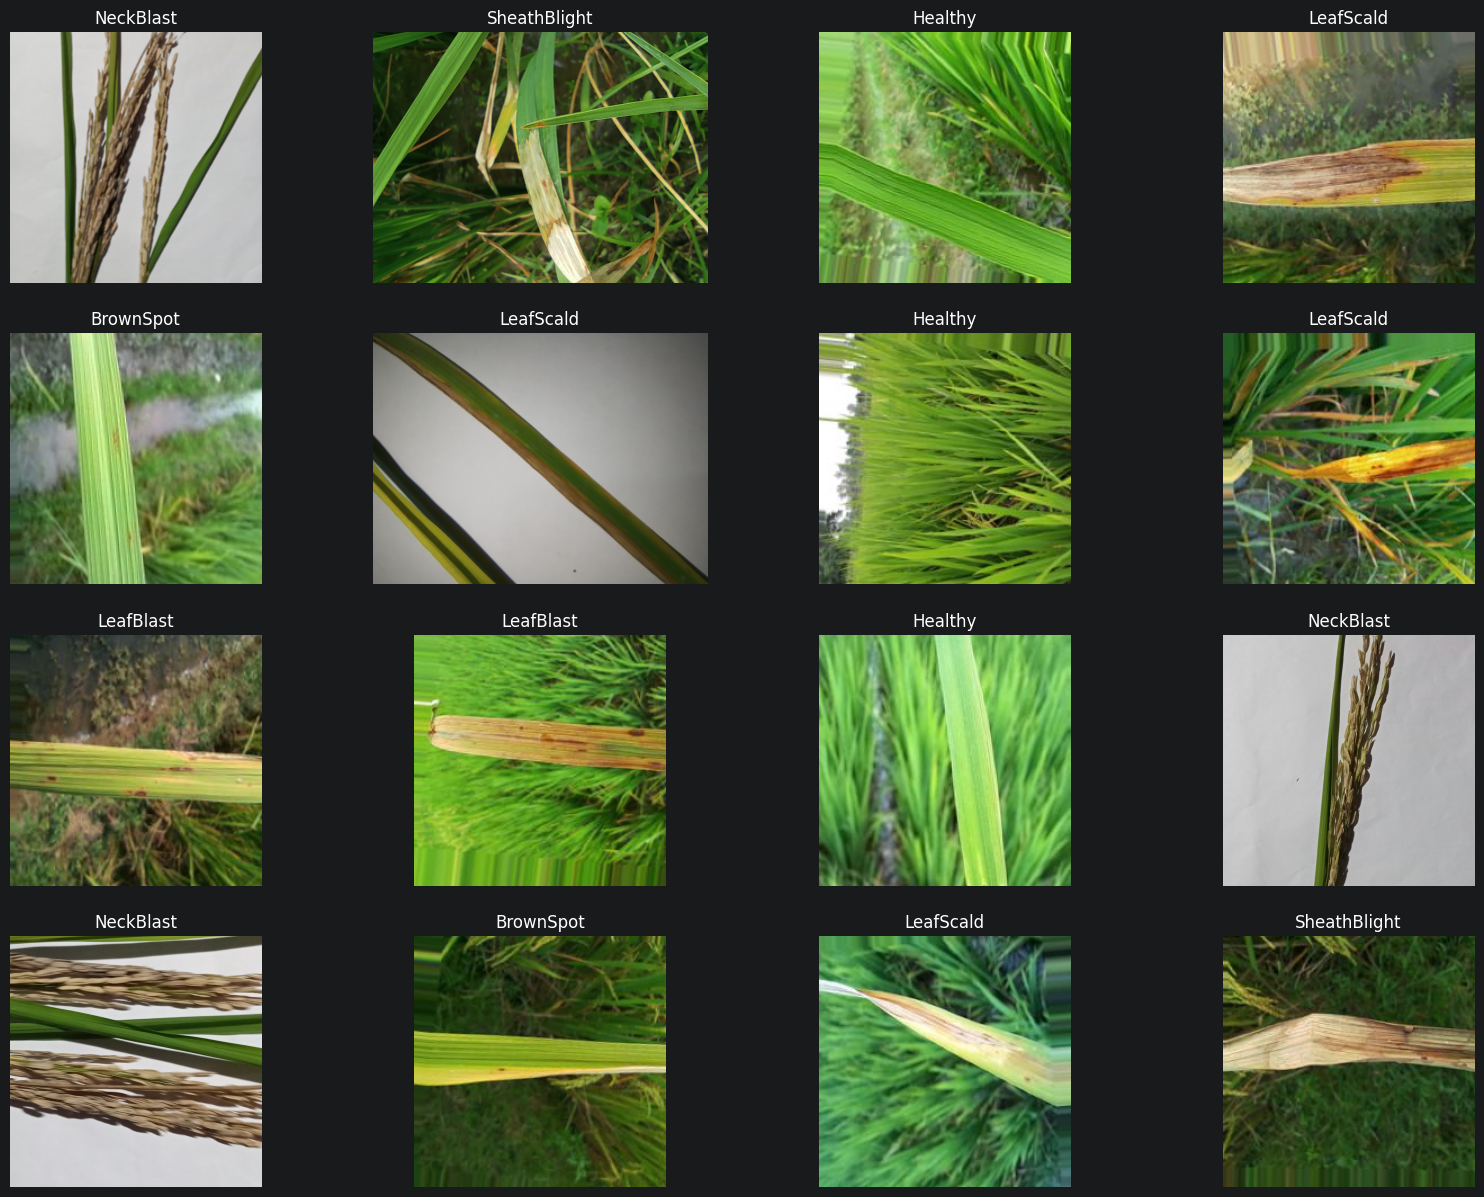

In [3]:
fix , ax = plt.subplots(4,4 , figsize = (20,15))
ax = ax.ravel()

for i in range(16):
    sample_df = train_df.sample(n = 1).iloc[0]
    img_path = sample_df['path']

    img = Image.open(img_path)
    ax[i].imshow(img)
    ax[i].set_title(sample_df['label'])
    ax[i].axis('off')

plt.show()


## 3. Transform anh ve 60 X 60

In [4]:
transform = transforms.Compose([
    transforms.Resize((60,60)),
    transforms.ToTensor()
])

## 4. Crate dataset class

In [5]:
class Dataset ():
    def __init__(self , dir , df , transform = None):
        self.dir = dir
        self.df =  df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self , idx):
        img_path = os.path.join(self.dir ,
                                self.df.iloc[idx]['label'],
                                self.df.iloc[idx]['path']
                                )
        img = Image.open(img_path).convert('RGB')

        if self.df.iloc[idx]['label'] == 'Healthy':
            label = 0
        elif self.df.iloc[idx]['label'] == 'BrownSpot':
            label = 1
        elif self.df.iloc[idx]['label'] == 'LeafBlast':
            label = 2
        elif self.df.iloc[idx]['label'] == 'Hispa':
            label = 3
        elif self.df.iloc[idx]['label'] == 'LeafScald':
            label = 4
        elif self.df.iloc[idx]['label'] == 'LeafBlight':
            label = 5
        elif self.df.iloc[idx]['label'] == 'NeckBlast':
            label = 6
        elif self.df.iloc[idx]['label'] == 'SheathBlight':
            label = 7


        if self.transform:
            img = self.transform(img)

        return img , label


## 5 . Create Train , Test oject

In [6]:
train_dir = '/Users/nguyenxuankhanh/Downloads/Project_ML_AI/rice_dataset_ok/train'

test_dir = '/Users/nguyenxuankhanh/Downloads/Project_ML_AI/rice_dataset_ok/test'

train = Dataset(train_dir,train_df , transform)
test = Dataset(test_dir,test_df , transform)

In [7]:
## Get the length
print(len(train))
print(len(test))

6400
1600


<Axes: xlabel='label'>

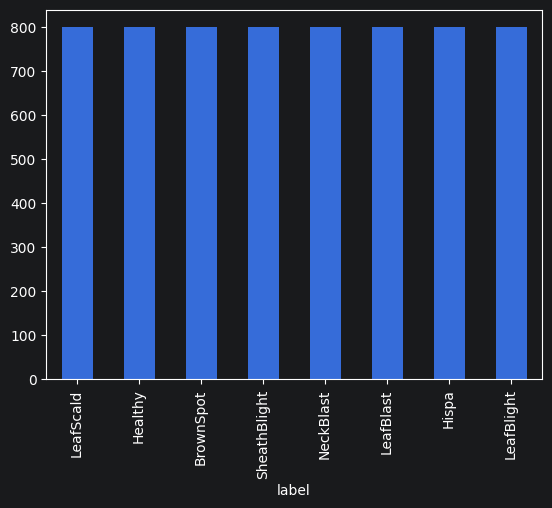

In [8]:
## Plot bar graph

train_df['label'].value_counts().plot(kind='bar')

## 6. Creat Datasets

In [10]:
# train_dataset = torch.utils.data.DataLoader(train , batch_size = 32 , shuffle = True, num_workers = 4)
# test_dataset = torch.utils.data.DataLoader(test , batch_size = 32 , shuffle = True, num_workers = 4)
#
# print(len(train_dataset))
# print(len(test_dataset))

200
50


In [9]:
print(train.__getitem__(0)[0].shape)

torch.Size([3, 60, 60])


## 7. Plot img [3, 60 , 60]

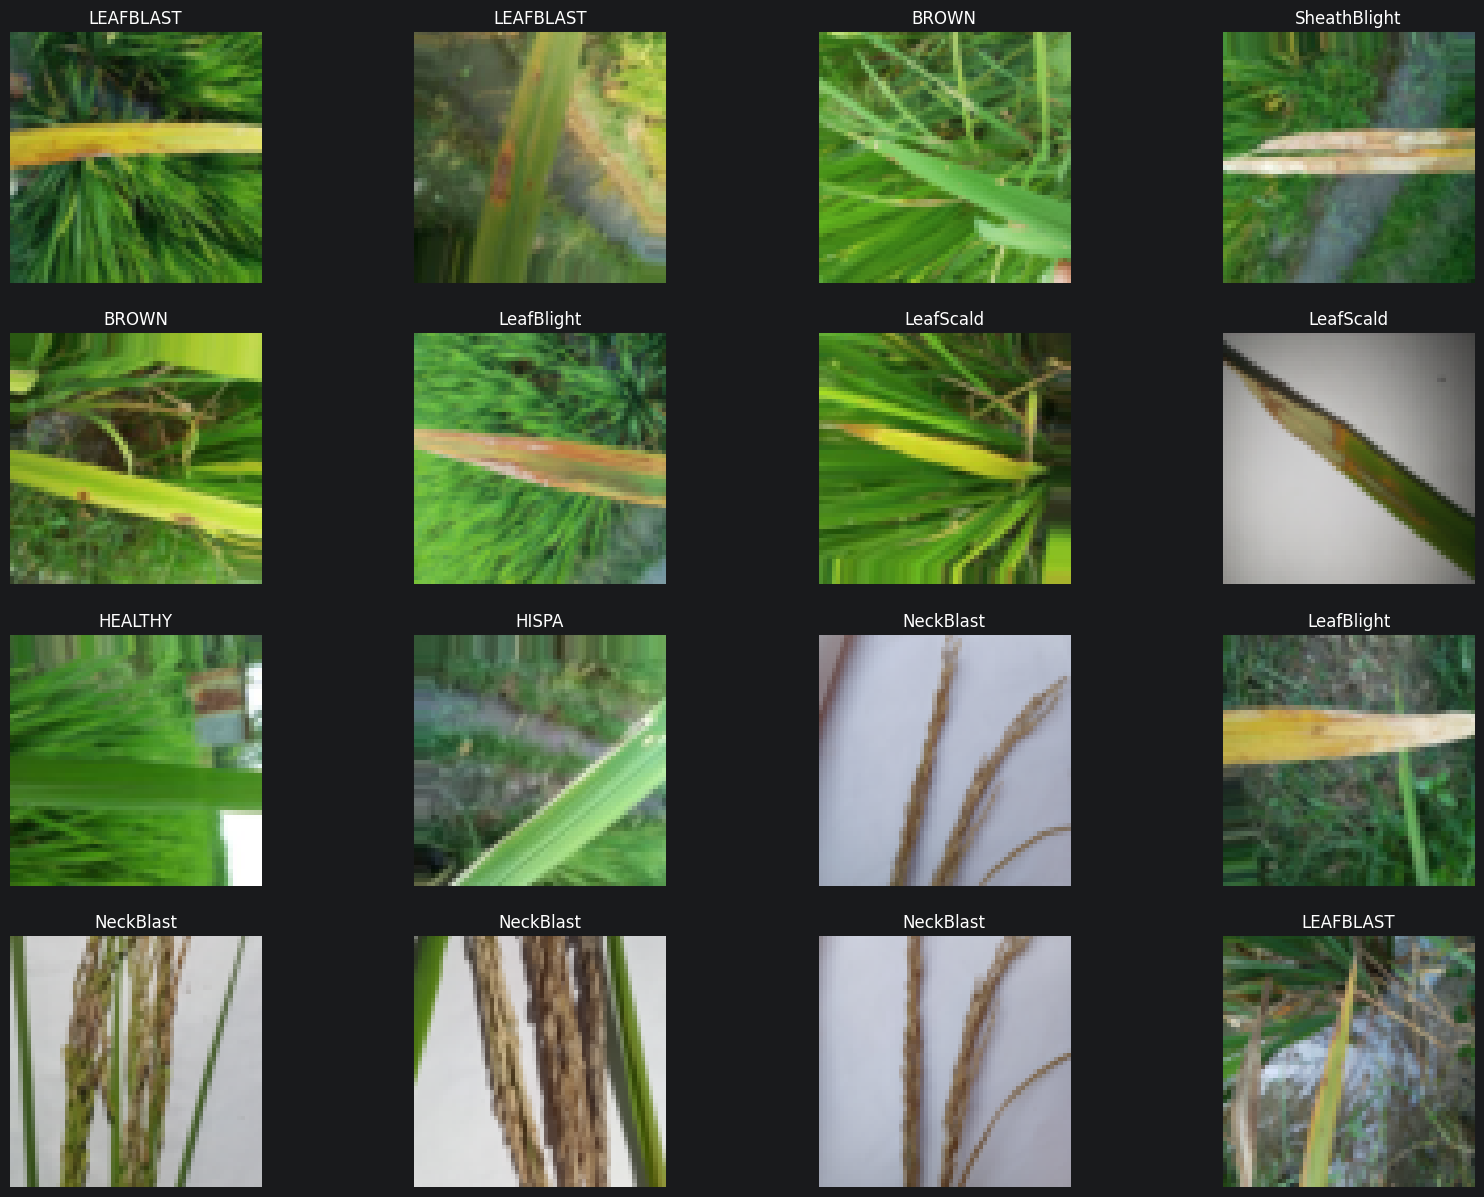

In [10]:
train_loader = DataLoader(
    train,
    batch_size=16,
    shuffle=True
)
test_loader = DataLoader(
    test,
    batch_size=32,
    shuffle=False
)

sample_df , labels  = next(iter(train_loader))
fig , axes = plt.subplots(4,4 , figsize = (20,15))
axes = axes.ravel()


for i in range(16):
    axes[i].imshow(sample_df[i].permute(1,2,0))# (C , H  , W ) -> (H , W ,C)
    if labels[i] == 0:
        axes[i].set_title('HEALTHY')
    elif labels[i] == 1:
        axes[i].set_title('BROWN')
    elif labels[i] == 2:
        axes[i].set_title('LEAFBLAST')
    elif labels[i] == 3:
        axes[i].set_title('HISPA')
    elif labels[i] == 4:
        axes[i].set_title('LeafScald')
    elif labels[i] == 5:
        axes[i].set_title('LeafBlight')
    elif labels[i] == 6:
        axes[i].set_title('NeckBlast')
    elif labels[i] == 7:
        axes[i].set_title('SheathBlight')
    axes[i].axis('off')


## 8 . Create CNN model

In [17]:
import  torch.nn as nn


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.conv3 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 5 * 5, 256)
        self.fc2 = nn.Linear(256, 128)

        # 8 class
        self.fc3 = nn.Linear(128, 8)
        self.softmax = nn.LogSoftmax(dim=1)  # Ne1 = 0,2 -> Net2 = 0,8

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.flatten(x)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)
        x = self.softmax(x)

        return x

model = CNN().to(device)



## 9 . Get the model Summary

In [18]:
from  torchsummary import  summary

summary(model, (3,60,60))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 58, 58]             448
         MaxPool2d-2           [-1, 16, 29, 29]               0
            Conv2d-3           [-1, 32, 27, 27]           4,640
         MaxPool2d-4           [-1, 32, 13, 13]               0
            Conv2d-5           [-1, 64, 11, 11]          18,496
         MaxPool2d-6             [-1, 64, 5, 5]               0
           Flatten-7                 [-1, 1600]               0
            Linear-8                  [-1, 256]         409,856
            Linear-9                  [-1, 128]          32,896
           Linear-10                    [-1, 8]           1,032
       LogSoftmax-11                    [-1, 8]               0
Total params: 467,368
Trainable params: 467,368
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.04
Forward/

## 10 . Optimizer

In [19]:
Tieu_chuan = nn.CrossEntropyLoss().to(device)
Optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
epochs = 50

## 11 . Train model

In [20]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

Train_loss = []
Train_accuracy =[]
Test_loss =[]
Test_accuracy =[]

for epoch in range(epochs):
    model.train()
    total = 0
    correct = 0
    train_loss = 0

    for data , label in train_loader:
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = Tieu_chuan(output, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        total += label.size(0)
        _,pred = torch.max(output, 1)

        correct += (pred == label).sum().item()

    Train_accuracy.append(100* (correct / total))
    Train_loss.append(train_loss/len(train_loader))
    print(f'Epoch :{epoch+1} Training loss : {train_loss / len(train_loader)} Training Accuracy : {100*(correct / total)}')

    with torch.no_grad():
        model.eval()
        correct = 0
        test_loss = 0.0
        total_test = 0
        for test_data , test_label in test_loader:
            data, label = test_data.to(device), test_label.to(device)
            output = model(data)
            loss = Tieu_chuan(output, label)
            test_loss += loss.item()
            total_test += label.size(0)
            _,test_pred = torch.max(output, 1)
            correct += (test_pred == label).sum().item()
        Test_accuracy.append(100* (correct / total_test))
        Test_loss.append(test_loss / len(test_loader))

        print(f'Epoch :{epoch+1} Test loss : {test_loss / len(test_loader)} Test Accuracy : {100*(correct /total_test)}')

Epoch :1 Training loss : 1.5677787086367607 Training Accuracy : 36.90625
Epoch :1 Test loss : 1.2278698933124543 Test Accuracy : 50.31250000000001
Epoch :2 Training loss : 1.1319213896989821 Training Accuracy : 55.26562499999999
Epoch :2 Test loss : 1.1418336617946625 Test Accuracy : 56.3125
Epoch :3 Training loss : 0.949635005965829 Training Accuracy : 63.84375
Epoch :3 Test loss : 0.9197670018672943 Test Accuracy : 63.74999999999999
Epoch :4 Training loss : 0.8489876247942447 Training Accuracy : 67.3125
Epoch :4 Test loss : 0.9089017879962921 Test Accuracy : 65.5
Epoch :5 Training loss : 0.760876419134438 Training Accuracy : 71.859375
Epoch :5 Test loss : 0.7825613218545914 Test Accuracy : 70.5625
Epoch :6 Training loss : 0.665962808355689 Training Accuracy : 75.4375
Epoch :6 Test loss : 0.7390454429388046 Test Accuracy : 72.25
Epoch :7 Training loss : 0.5861276539042592 Training Accuracy : 78.296875
Epoch :7 Test loss : 0.662395858168602 Test Accuracy : 76.1875
Epoch :8 Training los

## 12 . Biểu đồ train test

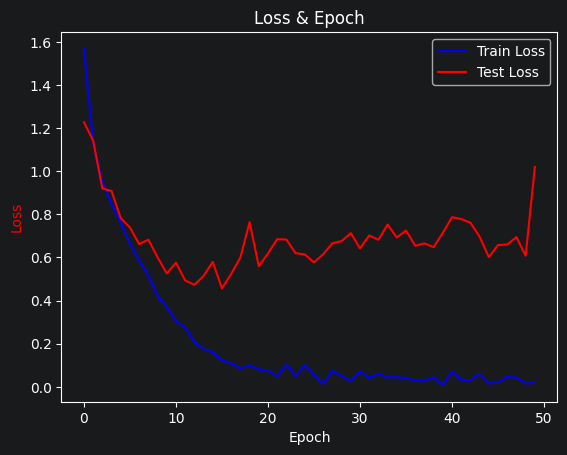

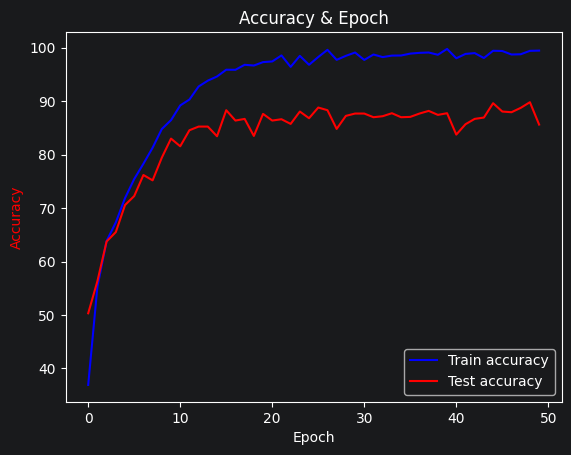

In [23]:
epoch = [*range(epochs)]
fig , ax1 = plt.subplots()
ax1.plot(epoch,Train_loss,'b-',label = 'Train Loss')
ax1.plot(epoch,Test_loss,'r-',label = 'Test Loss')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='r')
ax1.set_title('Loss & Epoch')
ax1.legend()
plt.show()

fig , ax2 = plt.subplots()
ax2.plot(epoch,Train_accuracy,'b-',label = 'Train accuracy')
ax2.plot(epoch,Test_accuracy,'r-',label = 'Test accuracy')

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy' , color='r')
ax2.set_title('Accuracy & Epoch')
ax2.legend()
plt.show()



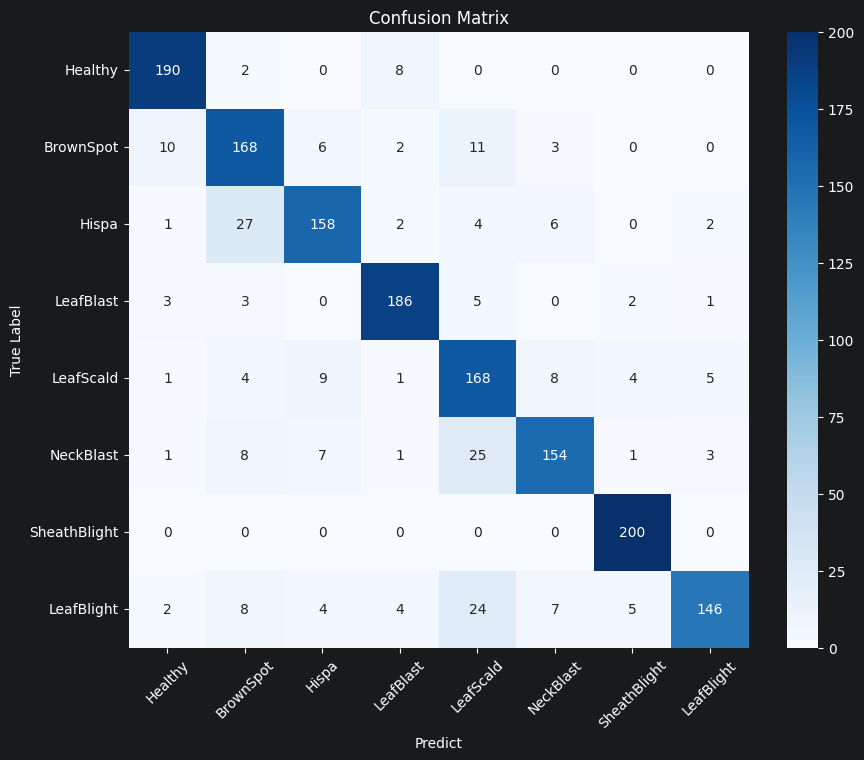

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Chuyển model sang eval
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for data, labels in test_loader:

        data = data.to(device)
        labels = labels.to(device)

        outputs = model(data)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# Tên class
class_names = [
    'Healthy',
    'BrownSpot',
    'Hispa',
    'LeafBlast',
    'LeafScald',
    'NeckBlast',
    'SheathBlight',
    'LeafBlight']

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predict')

plt.ylabel('True Label')

plt.title('Confusion Matrix')

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

In [28]:
torch.save(model, 'rice_model_ok.pth')
print("Đã lưu model thành công!")

Đã lưu model thành công!


## Load model